In [1]:
import pandas as pd

df = pd.read_csv('cleaned_data.csv')

for col in df.columns:
    print(col) 

Date of Surgery
Sex
Age
LLIF?
Case/Type of Surgery
Perc screws?
Open
Open Check V2
Standalone XLIF Check
 Retroperitoneal Approach (LLIF ± ALIF)
Anterior + Posterior Apporoach
Osteotomies (yes/no)
osteotomy level
T12-L1
L1-L2
L2-L3
L3-L4
L4-L5
L5-S1
ALIF Count
Lateral Count
ACR (y=1)
ACR level
Additional Procedures w/in surgery
Pre op Diagnosis (back pain, adjacent segment disease, spondy)
BMI
prior back surgeries? (y=1)
Average PI
VALIDATION COLUMN
PI-LL angle mismatch
ABS PI-LL angle mismatch
PI-LL Mismatch Category (1 = mismatch > +/- 9
PI-LL Mismatch Category (1 = mismatch > +/- 10
(1 = PI>50)
Post-op SS
Post-op SS Grouping
Roussouly Class
post PI
post PT
post LL
post SVA
post-op date
most recent PI
most recent PT
most recent LL
most recent SVA
most recent date
subsidence 
titanium v PEEK (T=0,P=1)
cage details
length of hospital stay (d)
post op complications? (Y/N)
infection 1=yes
DVT  1=yes
PE  1=yes
MI 1=yes
infection 
DVT
PE
MI
Hernia
Hematoma
femoral palsy (knee extension wea

In [2]:
clean_feature_cols = [

    # Demographics
    "Sex",
    "Age",
    "BMI",
    "prior back surgeries? (y=1)",

    # Pre-op diagnosis
    "dx_adjacent_segment",
    "dx_spondylolisthesis",
    "dx_spondylosis",
    "dx_stenosis",
    "dx_scoliosis",
    "dx_flat_back",
    "dx_sagittal_imbalance",
    "dx_post_laminectomy",
    "dx_deformity",

    # Case type
    "Case/Type of Surgery",
    "Additional Procedures w/in surgery",

    # Fusion levels
    "T12-L1",
    "L1-L2",
    "L2-L3",
    "L3-L4",
    "L4-L5",
    "L5-S1",

    # Surgical approach / technique
    "Perc screws?",
    "Open",
    "Open Check V2",
    "Standalone XLIF Check",
    "Retroperitoneal Approach (LLIF ± ALIF)",
    "Anterior + Posterior Apporoach",
    "Osteotomies (yes/no)",
    "osteotomy level",
    "ALIF Count",
    "Lateral Count",
    "ACR (y=1)",
    "ACR level",

    # Preoperative spinopelvic parameters
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "PI-LL Mismatch Category (1 = mismatch > +/- 9",
    "PI-LL Mismatch Category (1 = mismatch > +/- 10",
    "(1 = PI>50)",

    # Immediate postoperative alignment (allowed)
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",

    # Immediate postop complications (allowed)
    "infection 1=yes",
    "DVT  1=yes",
    "PE  1=yes",
    "MI 1=yes",
    "femoral palsy (knee extension weakness) 1=yes",
    "hip flexion weakness (iliopsoas weakness)  1=yes",
    "acute thigh paresthesia (immediate post op)",
    "psoas hematoma",

    # Hospital course
    "length of hospital stay (d)",
]


In [3]:
clean_feature_cols_asd = [

    # -----------------
    # Demographics
    # -----------------
    "Sex",
    "Age",
    "BMI",
    "prior back surgeries? (y=1)",

    # -----------------
    # Pre-op diagnosis flags (from Pre op Diagnosis text)
    # -----------------
    "dx_adjacent_segment",
    "dx_spondylolisthesis",
    "dx_spondylosis",
    "dx_stenosis",
    "dx_scoliosis",
    "dx_flat_back",
    "dx_sagittal_imbalance",
    "dx_post_laminectomy",
    "dx_deformity",
    "Case/Type of Surgery",


    # -----------------
    # Fusion levels (index constructs)
    # -----------------
    "T12-L1",
    "L1-L2",
    "L2-L3",
    "L3-L4",
    "L4-L5",
    "L5-S1",

    # Construct summary features you engineered
    "levels_fused_count",
    "construct_span_levels",
    "thoracolumbar_junction",
    "upper_lumbar",
    "lower_lumbar",
    "lumbosacral",

    # -----------------
    # Surgical approach / technique
    # -----------------
    "LLIF?",                # whether lateral/LLIF was done at all
    "Perc screws?",
    "Open",
    "Open Check V2",
    "Standalone XLIF Check",
    "Retroperitoneal Approach (LLIF ± ALIF)",
    "Anterior + Posterior Apporoach",
    "Osteotomies (yes/no)",
    "osteotomy level",
    "ALIF Count",
    "Lateral Count",
    "ACR (y=1)",
    "ACR level",

    # Higher-level surgery flags
    "revision_surgery",
    "deformity_case_text",
    "llif_or_lateral_text",
    "xlif_text",
    "alif_text",

    # -----------------
    # Preoperative spinopelvic parameters
    # -----------------
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "PI-LL Mismatch Category (1 = mismatch > +/- 9",
    "PI-LL Mismatch Category (1 = mismatch > +/- 10",
    "(1 = PI>50)",   # this matches your full column list

    # -----------------
    # Immediate postoperative alignment (non-leaky)
    # -----------------
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",

    # -----------------
    # Immediate postop complications (index hospitalization)
    # -----------------
    "infection 1=yes",
    "DVT  1=yes",
    "PE  1=yes",
    "MI 1=yes",
    "femoral palsy (knee extension weakness) 1=yes",
    "hip flexion weakness (iliopsoas weakness)  1=yes",
    "acute thigh paresthesia (immediate post op)",
    "psoas hematoma",

    # -----------------
    # Hospital course
    # -----------------
    "length of hospital stay (d)",
]


In [4]:
import pandas as pd
import numpy as np
from sksurv.util import Surv
from sklearn.model_selection import train_test_split

time_col = "Time Until ASD Diagnosis (months)"


C:\Users\shrin\AppData\Local\Temp\ipykernel_35212\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")
C:\Users\shrin\AppData\Local\Temp\ipykernel_35212\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")
C:\Users\shrin\AppData\Local\Temp\ipykernel_35212\341787359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=series, order=order, ax=ax, palette="muted")


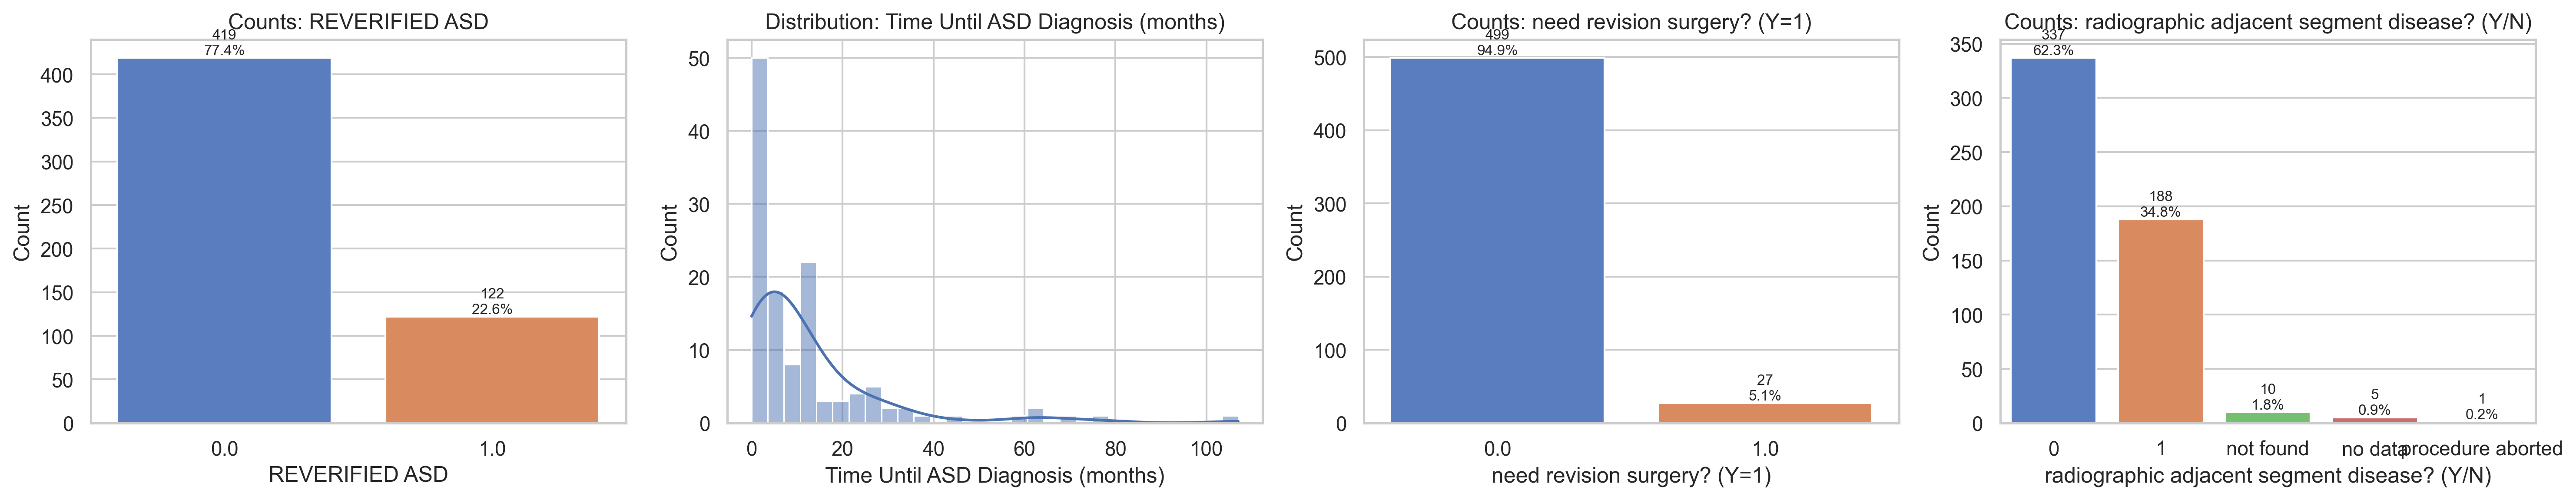

In [5]:
import seaborn as sns
from pandas.api import types as pd_types

import matplotlib.pyplot as plt

# helper to find column with case-insensitive / partial matching
def find_col(df, name):
    name_l = name.lower()
    # exact lower match
    for c in df.columns:
        if c.lower() == name_l:
            return c
    # substring match
    for c in df.columns:
        if name_l in c.lower() or c.lower() in name_l:
            return c
    return None

# desired columns (use existing notebook variables where available)
cols_wanted = [
    "REVERIFIED ASD",                    # user: 'Reverified ASD'
    time_col,                            # 'Time Until ASD Diagnosis (months)' (variable from notebook)
    "need revision surgery? (Y=1)",      # user-provided name
    "radiographic adjacent segment disease? (Y/N)"
]

# resolve to actual df columns, skip missing
cols = []
for nm in cols_wanted:
    c = find_col(df, nm)
    if c is None:
        print(f"Column not found (skipping): {nm}")
    else:
        cols.append(c)

if not cols:
    raise RuntimeError("No plotting columns found in df.")

sns.set(style="whitegrid")

n = len(cols)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), dpi=300, squeeze=False)
axes = axes.flatten()

for ax, col in zip(axes, cols):
    series = df[col].dropna()
    # decide continuous vs categorical/binary
    is_numeric = pd_types.is_numeric_dtype(series.dtype)
    unique_vals = series.nunique(dropna=True)
    if is_numeric and unique_vals > 10:
        # distribution for continuous
        sns.histplot(series.astype(float), kde=True, bins=30, ax=ax, color="C0")
        ax.set_title(f"Distribution: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    else:
        # histogram / countplot for categorical / binary
        order = series.value_counts(dropna=True).index
        sns.countplot(x=series, order=order, ax=ax, palette="muted")
        ax.set_title(f"Counts: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
        # annotate counts / percentages
        totals = len(series)
        for p in ax.patches:
            height = p.get_height()
            if height == 0:
                continue
            pct = 100 * height / totals
            ax.annotate(f"{int(height)}\n{pct:.1f}%", (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd


# 2. Clean column names a bit
df.columns = (
    df.columns
      .str.strip()
      .str.replace("\n", " ", regex=False)
)

df.columns



Index(['Date of Surgery', 'Sex', 'Age', 'LLIF?', 'Case/Type of Surgery',
       'Perc screws?', 'Open', 'Open Check V2', 'Standalone XLIF Check',
       'Retroperitoneal Approach (LLIF ± ALIF)',
       ...
       'alif_text', 'dx_adjacent_segment', 'dx_spondylolisthesis',
       'dx_spondylosis', 'dx_stenosis', 'dx_scoliosis', 'dx_flat_back',
       'dx_sagittal_imbalance', 'dx_post_laminectomy', 'dx_deformity'],
      dtype='str', length=116)

In [7]:
target = "Time Until ASD Diagnosis (months)"

# Keep only rows where the target is known (patients who actually developed ASD)
asd_df = df[df[target].notna()].copy()
asd_df.shape


(125, 116)

In [8]:
import pandas as pd
import numpy as np

from sksurv.util import Surv
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from numpy.linalg import LinAlgError

import torch
import torchtuples as tt
from pycox.models import CoxPH as CoxPH_NN

# ---------------------------
# 1. Define columns & labels
# ---------------------------

event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"   # used ONLY for label, not as feature

# df is assumed to be your cleaned dataframe (e.g. df_lace or df_clean)

df_surv = df.copy()

# event: 1 if ASD, else 0
df_surv[event_col] = df_surv[event_col].fillna(0).astype(int)

# time: ASD time if event==1, otherwise Time Without_ASD
df_surv["time_surv"] = np.where(
    df_surv[event_col] == 1,
    df_surv[time_asd_col],
    df_surv[time_no_asd_col],
)

# Drop rows with missing survival time
df_surv = df_surv.dropna(subset=["time_surv"])

print("Full cohort survival rows:", df_surv.shape[0])
print("Events (ASD):", int(df_surv[event_col].sum()))
print("Non-events:", int((df_surv[event_col] == 0).sum()))

# ---------------------------------
# 2. Feature preprocessing
# ---------------------------------

X = df_surv[clean_feature_cols_asd].copy()

# 2a. Coerce numeric-like columns
numeric_like_cols = [
    "BMI",
    "ALIF Count",
    "Lateral Count",
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",
    "length of hospital stay (d)",
]

for col in numeric_like_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# 2b. One-hot encode categorical columns
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Categorical feature columns:", cat_cols)

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Simple imputation: fill remaining NaNs
X_encoded = X_encoded.fillna(0)

# Targets
durations_all = df_surv["time_surv"].astype(float).values
events_all = df_surv[event_col].astype(bool).values

print("Final feature matrix shape:", X_encoded.shape)

# ---------------------------------
# 3. Cross-validated classical survival models
# ---------------------------------

# Define models (we'll re-instantiate them inside each fold)
def build_models():
    return {
        "coxph": CoxPHSurvivalAnalysis(alpha=1.0),
        "rsf": RandomSurvivalForest(
            n_estimators=300,
            min_samples_split=10,
            min_samples_leaf=10,
            n_jobs=-1,
            random_state=42,
        ),
        "gbsa": GradientBoostingSurvivalAnalysis(
            learning_rate=0.05,
            max_depth=3,
            n_estimators=300,
            random_state=42,
        ),
    }

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

cv_results = {name: [] for name in build_models().keys()}
cv_results_deepsurv = []

X_values = X_encoded.values

fold_idx = 1

for train_idx, test_idx in skf.split(X_values, events_all):
    print(f"\n===== Fold {fold_idx}/{n_splits} =====")
    fold_idx += 1

    X_train = X_values[train_idx]
    X_test = X_values[test_idx]
    durations_train = durations_all[train_idx]
    durations_test = durations_all[test_idx]
    events_train = events_all[train_idx]
    events_test = events_all[test_idx]

    # Build sksurv Surv objects
    y_train = Surv.from_arrays(event=events_train, time=durations_train)
    y_test = Surv.from_arrays(event=events_test, time=durations_test)

    # ------------------
    # Classical models
    # ------------------
    models = build_models()

    for name, model in models.items():
        try:
            model.fit(X_train, y_train)
            pred = model.predict(X_test)
            ci = concordance_index_censored(
                events_test,
                durations_test,
                pred
            )[0]
            cv_results[name].append(ci)
            print(f"{name} C-index (fold): {ci:.3f}")
        except LinAlgError:
            print(f"Skipping {name} in this fold: singular matrix.")
            cv_results[name].append(np.nan)


# ---------------------------------
# 4. Summarize CV results
# ---------------------------------

print("\n===== Cross-validated C-index (mean ± SD) =====")
for name, scores in cv_results.items():
    scores_arr = np.array(scores, dtype=float)
    mean_ci = np.nanmean(scores_arr)
    std_ci = np.nanstd(scores_arr)
    print(f"{name}: {mean_ci:.3f} ± {std_ci:.3f} over {n_splits} folds")



Full cohort survival rows: 546
Events (ASD): 122
Non-events: 424
Categorical feature columns: ['Case/Type of Surgery', 'osteotomy level', 'ACR level']
Final feature matrix shape: (546, 389)

===== Fold 1/10 =====


C:\Users\shrin\AppData\Local\Temp\ipykernel_35212\1425106020.py:73: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


coxph C-index (fold): 0.461
rsf C-index (fold): 0.434
gbsa C-index (fold): 0.466

===== Fold 2/10 =====
coxph C-index (fold): 0.435
rsf C-index (fold): 0.489
gbsa C-index (fold): 0.511

===== Fold 3/10 =====
coxph C-index (fold): 0.515
rsf C-index (fold): 0.615
gbsa C-index (fold): 0.542

===== Fold 4/10 =====
coxph C-index (fold): 0.520
rsf C-index (fold): 0.666
gbsa C-index (fold): 0.602

===== Fold 5/10 =====
coxph C-index (fold): 0.564
rsf C-index (fold): 0.607
gbsa C-index (fold): 0.552

===== Fold 6/10 =====
coxph C-index (fold): 0.454
rsf C-index (fold): 0.584
gbsa C-index (fold): 0.541

===== Fold 7/10 =====
coxph C-index (fold): 0.614
rsf C-index (fold): 0.518
gbsa C-index (fold): 0.505

===== Fold 8/10 =====
coxph C-index (fold): 0.790
rsf C-index (fold): 0.846
gbsa C-index (fold): 0.686

===== Fold 9/10 =====
coxph C-index (fold): 0.542
rsf C-index (fold): 0.698
gbsa C-index (fold): 0.665

===== Fold 10/10 =====
coxph C-index (fold): 0.502
rsf C-index (fold): 0.502
gbsa C-in

Cohort rows: 546 Events: 122
Categorical feature columns: ['Case/Type of Surgery', 'Additional Procedures w/in surgery', 'osteotomy level', 'ACR level']
Initial feature matrix shape: (546, 424)
Dropping 354 ultra-rare binary cols.
Shape after dropping ultra-rare columns: (546, 70)
Numeric-like columns for PCA: ['BMI', 'ALIF Count', 'Lateral Count', 'Average PI', 'PI-LL angle mismatch', 'ABS PI-LL angle mismatch', 'Post-op SS', 'post PI', 'post PT', 'post LL', 'post SVA', 'length of hospital stay (d)']
Replaced 12 numeric cols with 3 PCA components.
Final feature matrix shape (X_reduced): (546, 61)
Time grid: [ 0.   2.   3.   6.   8.  12.  18.  28.  53.5]
Calibration horizons: [ 3.  8. 23.]

--- Fold 1 ---


C:\Users\shrin\AppData\Local\Temp\ipykernel_35212\117915396.py:78: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()


 Fold C-index: 0.5121951219512195
 IBS error: time must be smaller than largest observed time point: 107.0
 Fold IBS: nan

--- Fold 2 ---
 Fold C-index: 0.5611510791366906
 Fold IBS: 0.18878313444472045

--- Fold 3 ---
 Fold C-index: 0.6272727272727273
 Fold IBS: 0.2031960046762385

--- Fold 4 ---
 Fold C-index: 0.6109660574412533
 Fold IBS: 0.1725212120689372

--- Fold 5 ---
 Fold C-index: 0.6688034188034188
 Fold IBS: 0.200739967149366

--- Fold 6 ---
 Fold C-index: 0.5567567567567567
 Fold IBS: 0.21079057170263432

--- Fold 7 ---
 Fold C-index: 0.49504950495049505
 Fold IBS: 0.16697811964155665

--- Fold 8 ---
 Fold C-index: 0.8111702127659575
 Fold IBS: 0.19810532366132785

--- Fold 9 ---
 Fold C-index: 0.6386292834890965
 Fold IBS: 0.18290878171571764

--- Fold 10 ---
 Fold C-index: 0.5108359133126935
 Fold IBS: 0.21443409496827032

=== CV SUMMARY ===
Per-fold C-index: [0.5122 0.5612 0.6273 0.611  0.6688 0.5568 0.495  0.8112 0.6386 0.5108]
Mean C-index: 0.5992830075880308
Per-fold

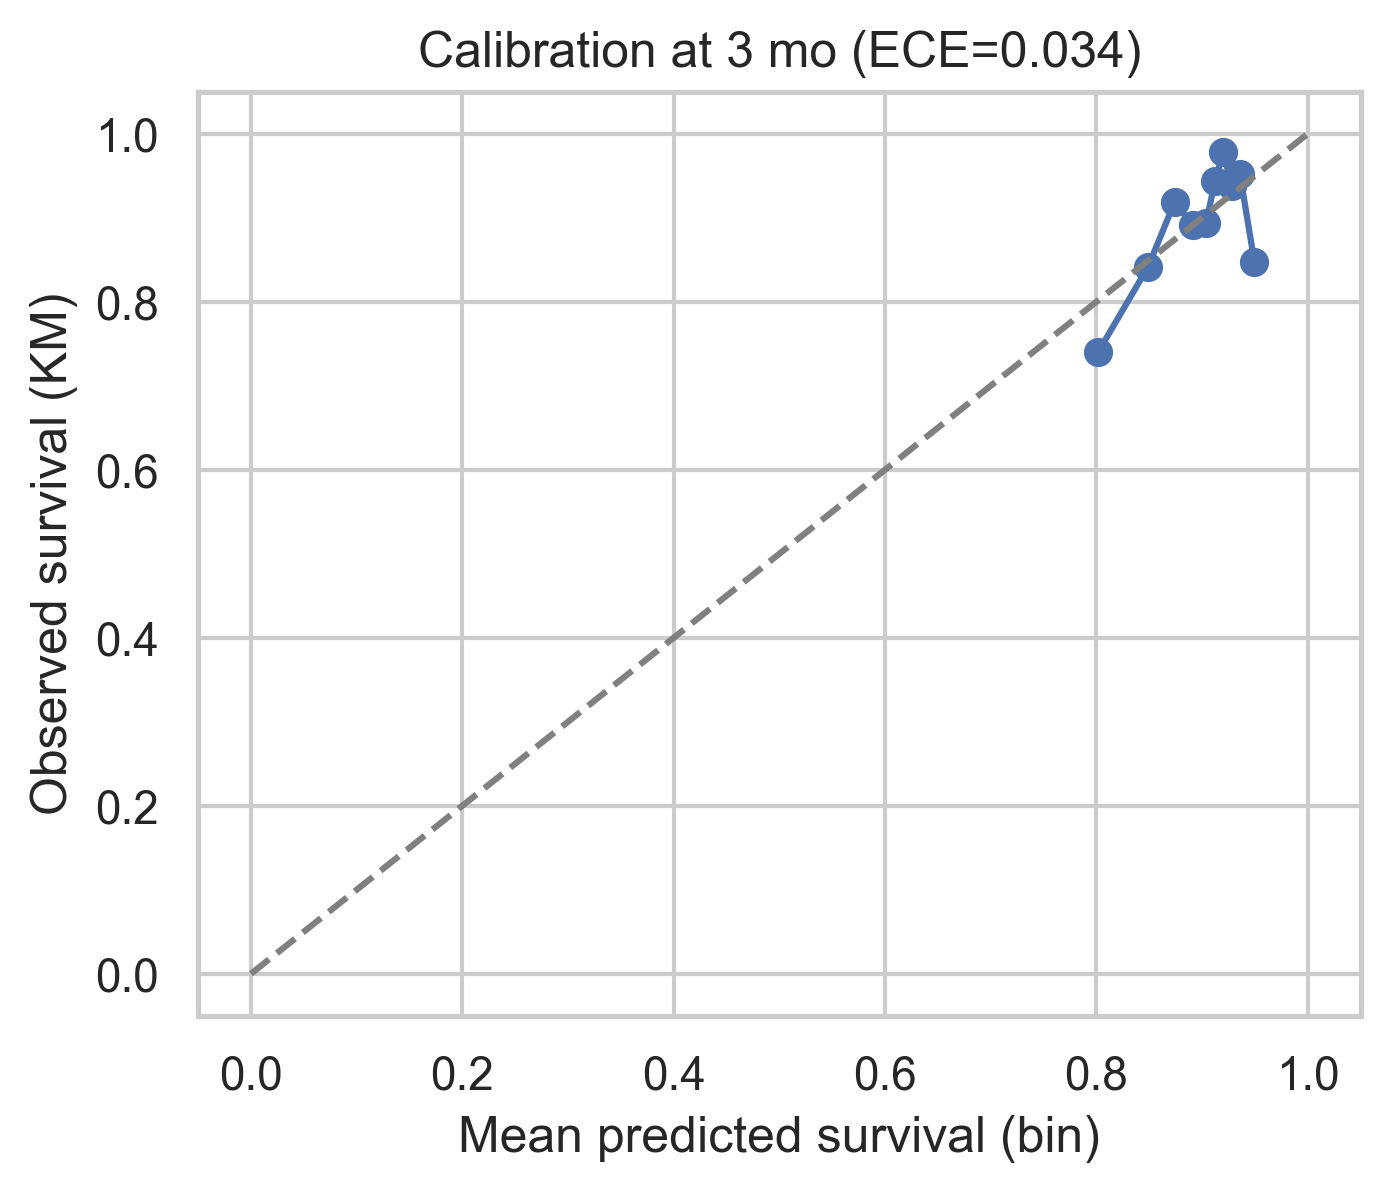

 Horizon 8.0 mo -> ECE = 0.0455


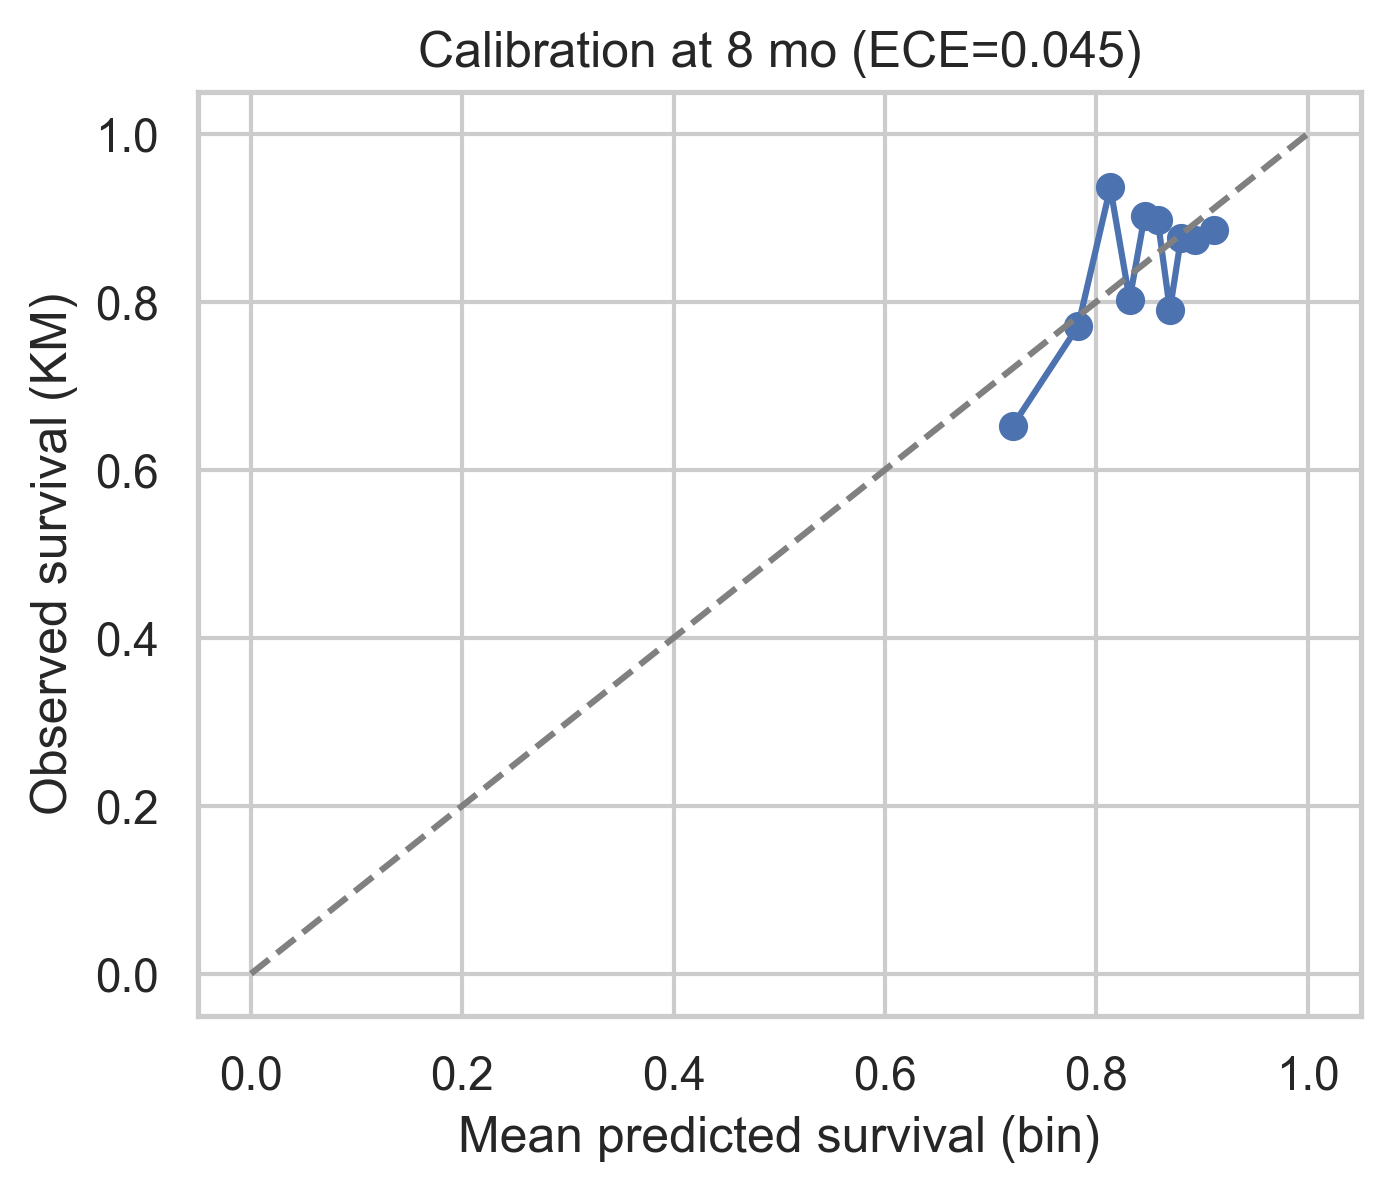

 Horizon 23.0 mo -> ECE = 0.0793


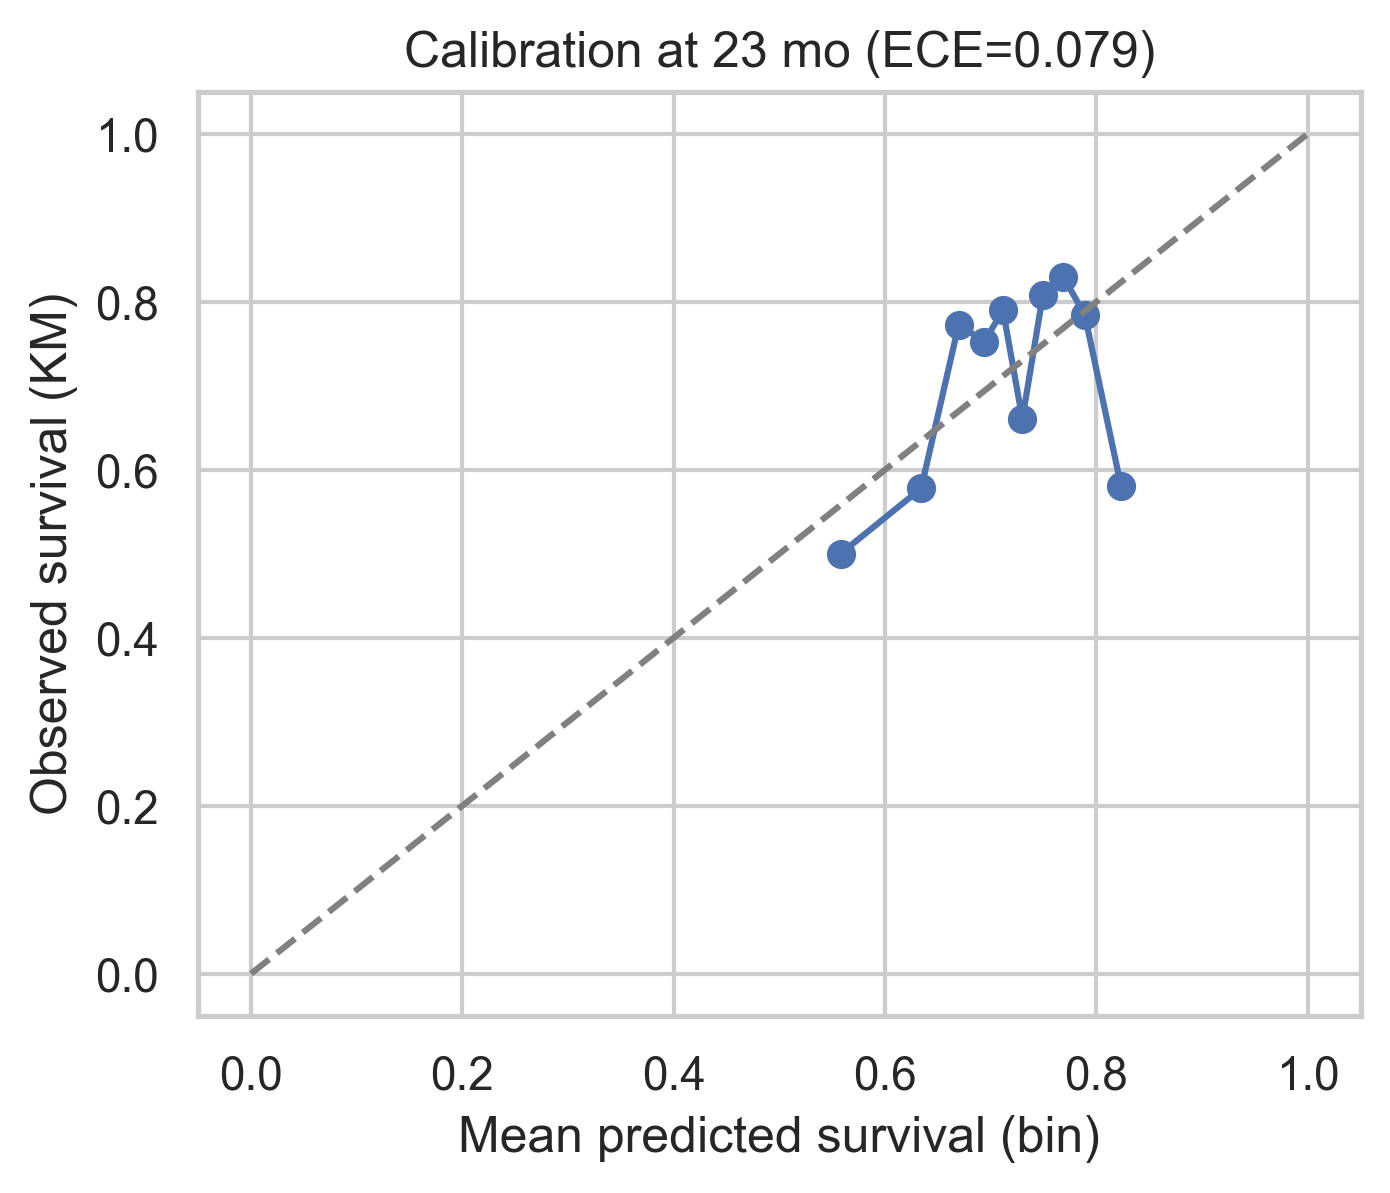


Saved final RSF model to: models/rsf_final_best.pkl


In [10]:
# -----------------------------
# Final pipeline: feature prep -> PCA -> RSF (fixed best params) -> metrics + save + unit test
# -----------------------------
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored, integrated_brier_score, cumulative_dynamic_auc
from lifelines import KaplanMeierFitter

# -----------------------------
# 0. CONFIG: best RSF params 
# -----------------------------
BEST_RSFPARAMS = {
    "n_estimators": 200,
    "min_samples_split": 4,
    "min_samples_leaf": 12,
    "max_features": "sqrt",
    "n_jobs": -1,
    "random_state": 42,
}

# -----------------------------
# 1. Survival labels & basic checks (assumes df available)
# -----------------------------
event_col = "REVERIFIED ASD"
time_asd_col = "Time Until ASD Diagnosis (months)"
time_no_asd_col = "Time Without_ASD (months)"

df_surv = df.copy()
df_surv[event_col] = df_surv.get(event_col, 0).fillna(0).astype(int)
df_surv["time_surv"] = np.where(
    df_surv[event_col] == 1,
    df_surv.get(time_asd_col),
    df_surv.get(time_no_asd_col),
)
df_surv = df_surv.dropna(subset=["time_surv"])
df_surv["time_surv"] = df_surv["time_surv"].astype(float)

print("Cohort rows:", df_surv.shape[0], "Events:", int(df_surv[event_col].sum()))

# -----------------------------
# 2. Feature construction 
# -----------------------------
# clean_feature_cols must exist (list of features you'd like to start from)
X = df_surv[clean_feature_cols].copy()

numeric_like_cols = [
    "BMI",
    "ALIF Count",
    "Lateral Count",
    "Average PI",
    "PI-LL angle mismatch",
    "ABS PI-LL angle mismatch",
    "Post-op SS",
    "post PI",
    "post PT",
    "post LL",
    "post SVA",
    "length of hospital stay (d)",
]

# coerce numeric-like
for col in numeric_like_cols:
    if col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

# one-hot encode categoricals
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
print("Categorical feature columns:", cat_cols)
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# simple imputation
X_encoded = X_encoded.fillna(0.0)

# targets
durations_all = df_surv["time_surv"].astype(float).values
events_all = df_surv[event_col].astype(bool).values

print("Initial feature matrix shape:", X_encoded.shape)

# -----------------------------
# 3. Remove ultra-rare binary features (occurence < 5)
# -----------------------------
binary_like_cols = [c for c in X_encoded.columns if set(np.unique(X_encoded[c])) <= {0,1}]
rare_cols = [c for c in binary_like_cols if X_encoded[c].sum() < 5]
print(f"Dropping {len(rare_cols)} ultra-rare binary cols.")
X_reduced = X_encoded.drop(columns=rare_cols)
print("Shape after dropping ultra-rare columns:", X_reduced.shape)

# -----------------------------
# 4. PCA compression 
# -----------------------------
numeric_present = [c for c in numeric_like_cols if c in X_reduced.columns]
print("Numeric-like columns for PCA:", numeric_present)

if len(numeric_present) >= 2:
    scaler_for_pca = StandardScaler()
    numeric_data = scaler_for_pca.fit_transform(X_reduced[numeric_present].values)
    n_pca = min(3, numeric_data.shape[1])
    pca = PCA(n_components=n_pca, random_state=42)
    pcs = pca.fit_transform(numeric_data)
    pca_cols = [f"pca_num_{i+1}" for i in range(n_pca)]
    df_pcs = pd.DataFrame(pcs, columns=pca_cols, index=X_reduced.index)
    X_reduced = pd.concat([X_reduced.drop(columns=numeric_present), df_pcs], axis=1)
    print(f"Replaced {len(numeric_present)} numeric cols with {n_pca} PCA components.")
else:
    print("Skipping PCA (not enough numeric-like columns).")

print("Final feature matrix shape (X_reduced):", X_reduced.shape)

# -----------------------------
# 5. Prepare CV and time grid
# -----------------------------
X_vals = X_reduced.values
events = events_all
times = durations_all

n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# time grid for IBS and time-AUC (use quantiles)
time_grid = np.percentile(times, np.linspace(10, 90, 9))  # e.g. 9 points
calib_times = list(np.percentile(times, [25, 50, 75]))    # calibration horizons

print("Time grid:", np.round(time_grid,2))
print("Calibration horizons:", np.round(calib_times,2))

# -----------------------------
# 6. CV: Fit RSF with fixed params, compute metrics per fold
# -----------------------------
rsf_fold_cis = []
rsf_fold_ibs = []
time_auc_folds = []
fold_predictions = []   # for calibration: store (test_idx, S_test_at_calib_times, t_te, e_te)

fold_id = 1
for train_idx, test_idx in skf.split(X_vals, events.astype(int)):
    print(f"\n--- Fold {fold_id} ---")
    X_tr, X_te = X_vals[train_idx], X_vals[test_idx]
    e_tr, e_te = events[train_idx], events[test_idx]
    t_tr, t_te = times[train_idx], times[test_idx]

    # skip fold if test has no events
    if int(e_te.sum()) == 0:
        print(" Skipping fold (no events in test).")
        rsf_fold_cis.append(np.nan)
        rsf_fold_ibs.append(np.nan)
        time_auc_folds.append((np.nan, np.nan))
        fold_predictions.append((None, None, (t_te, e_te)))
        fold_id += 1
        continue

    # structured arrays
    y_tr_struct = Surv.from_arrays(event=e_tr, time=t_tr)
    y_te_struct = Surv.from_arrays(event=e_te, time=t_te)

    # train RSF with best params
    rsf = RandomSurvivalForest(**BEST_RSFPARAMS)
    rsf.fit(X_tr, y_tr_struct)

    # risk predictions (for C-index and time-AUC)
    preds_risk = rsf.predict(X_te)
    try:
        ci = concordance_index_censored(e_te, t_te, preds_risk)[0]
    except Exception:
        ci = np.nan
    rsf_fold_cis.append(ci)
    print(" Fold C-index:", ci)

    # survival functions on test (list of step funcs) -> evaluate to array at time_grid
    surv_funcs_test = rsf.predict_survival_function(X_te, return_array=False)
    def eval_surv(surv_funcs, times_eval):
        arr = np.zeros((len(surv_funcs), len(times_eval)))
        for i, fn in enumerate(surv_funcs):
            xs = np.asarray(fn.x)
            ys = np.asarray(fn.y)
            arr[i,:] = np.interp(times_eval, xs, ys, left=1.0, right=ys[-1])
        return arr

    S_te = eval_surv(surv_funcs_test, time_grid)

    # IBS (integrated brier score) using sklearn-survival helper
    try:
        ibs = integrated_brier_score(y_tr_struct, y_te_struct, S_te, times=time_grid)
    except Exception as ex:
        print(" IBS error:", ex)
        ibs = np.nan
    rsf_fold_ibs.append(ibs)
    print(" Fold IBS:", ibs)

    # time-dependent AUC (cumulative_dynamic_auc) using risk scores
    try:
        times_auc, aucs = cumulative_dynamic_auc(y_tr_struct, y_te_struct, preds_risk, time_grid)
        time_auc_folds.append((times_auc, aucs))
    except Exception as ex:
        print(" time-AUC error:", ex)
        time_auc_folds.append((np.nan, np.nan))

    # store survival predictions at calibration horizons for calibration pooling
    S_test_calib = eval_surv(surv_funcs_test, calib_times)  # shape (n_test, n_calib_times)
    fold_predictions.append((test_idx, S_test_calib, (t_te, e_te)))

    fold_id += 1

# -----------------------------
# 7. Summarize CV metrics
# -----------------------------
print("\n=== CV SUMMARY ===")
print("Per-fold C-index:", np.round(rsf_fold_cis,4))
print("Mean C-index:", np.nanmean(rsf_fold_cis))
print("Per-fold IBS :", np.round(rsf_fold_ibs,5))
print("Mean IBS:", np.nanmean(rsf_fold_ibs))

# plot aggregated time-dependent AUC (mean ± std)
valid = [f for f in time_auc_folds if isinstance(f[1], (np.ndarray, list))]
if len(valid)>0:
    auc_stack = np.vstack([f[1] for f in valid])
    mean_auc = np.nanmean(auc_stack, axis=0)
    std_auc = np.nanstd(auc_stack, axis=0)
    plt.figure(figsize=(7,4))
    plt.plot(time_grid, mean_auc, lw=2, label="Mean time-dependent AUC")
    plt.fill_between(time_grid, np.maximum(0, mean_auc-std_auc), np.minimum(1, mean_auc+std_auc), alpha=0.2)
    plt.xlabel("Time (months)")
    plt.ylabel("AUC")
    plt.title("Time-dependent AUC (mean ± std) across CV folds")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print("No valid time-AUC results to plot.")

# -----------------------------
# 8. Calibration (ECE) at chosen horizons
# -----------------------------
def compute_ece_pooled(fold_preds, horizon_idx, n_bins=10):
    # pool predictions across folds
    rows = []
    for test_idx, S_test_calib, (t_te, e_te) in fold_preds:
        if S_test_calib is None:
            continue
        preds = S_test_calib[:, horizon_idx]
        rows.append(pd.DataFrame({"pred": preds, "time": t_te, "event": e_te}))
    if len(rows)==0:
        return None
    dfp = pd.concat(rows, ignore_index=True)
    # create bins by predicted survival probability
    dfp["bin"] = pd.qcut(dfp["pred"].rank(method="first"), q=n_bins, labels=False, duplicates="drop")
    bin_stats = []
    for b in sorted(dfp["bin"].dropna().unique()):
        sub = dfp[dfp["bin"]==b]
        if len(sub)==0:
            continue
        km = KaplanMeierFitter()
        try:
            km.fit(sub["time"], event_observed=sub["event"])
            obs = km.predict(calib_times[horizon_idx])
        except Exception:
            obs = np.nan
        pred_mean = sub["pred"].mean()
        bin_stats.append({"bin":b, "pred_mean": pred_mean, "obs": obs, "n": len(sub)})
    if len(bin_stats)==0:
        return None
    stats_df = pd.DataFrame(bin_stats)
    counts = stats_df["n"].values.astype(float)
    preds_arr = stats_df["pred_mean"].values.astype(float)
    obs_arr = stats_df["obs"].values.astype(float)
    ece = np.nansum((counts/np.sum(counts)) * np.abs(preds_arr - obs_arr))
    return {"ece": float(ece), "df": stats_df}

print("\nCalibration (ECE) results:")
calib_results = {}
for i, ct in enumerate(calib_times):
    res = compute_ece_pooled(fold_predictions, i, n_bins=10)
    calib_results[ct] = res
    if res is None:
        print(f" Horizon {ct:.1f}: insufficient data")
        continue
    print(f" Horizon {ct:.1f} mo -> ECE = {res['ece']:.4f}")
    # plot calibration
    dfplot = res["df"]
    plt.figure(figsize=(5,4), dpi=300)
    plt.plot(dfplot["pred_mean"], dfplot["obs"], marker="o", linestyle="-")
    plt.plot([0,1],[0,1], linestyle="--", color="gray")
    plt.xlabel("Mean predicted survival (bin)")
    plt.ylabel("Observed survival (KM)")
    plt.title(f"Calibration at {ct:.0f} mo (ECE={res['ece']:.3f})")
    plt.grid(True)
    plt.show()

# -----------------------------
# 9. Fit final RSF on full dataset and save model bundle
# -----------------------------
y_full = Surv.from_arrays(event=events, time=times)
rsf_final = RandomSurvivalForest(**BEST_RSFPARAMS)
rsf_final.fit(X_vals, y_full)

os.makedirs("models", exist_ok=True)
model_path = "models/rsf_final_best.pkl"
with open(model_path, "wb") as f:
    pickle.dump({"model": rsf_final, "feature_columns": X_reduced.columns.tolist(), "params": BEST_RSFPARAMS}, f)
print("\nSaved final RSF model to:", model_path)